## Metadados

Os dados foram obtidos a partir da plataforma [Kaggle](https://www.kaggle.com/), em um dataset público compilado por Arian Azmoudeh.

- **Fonte Principal:** [New York City Airbnb Open Data](https://www.kaggle.com/datasets/arianazmoudeh/airbnbopendata).

- **Fonte Original:** Os dados são derivados da iniciativa [Inside Airbnb](https://insideairbnb.com/explore/), que disponibiliza dados públicos sobre as listagens da plataforma em várias cidades do mundo.

### Sobre  o Airbnb

O Airbnb é uma plataforma que conecta pessoas que desejam alugar um espaço (como casas, apartamentos ou quartos) com viajantes em busca de acomodações temporárias. O serviço permite que anfitriões anunciem suas propriedades e que hóspedes reservem estadias, muitas vezes com preços mais acessíveis do que em hotéis tradicionais. 

### Sobre o Dataset

O dataset descreve a atividade de anúncios de acomodações na cidade de Nova York. As informações abrangem três áreas principais:

- **Anúncios (Listings):** Inclui descrições completas dos imóveis, localização geográfica (latitude e longitude), tipo de quarto, preço, regras da casa e informações sobre o anfitrião.
- **Avaliações (Reviews):** Contém dados sobre o número de avaliações, a data da última avaliação e a pontuação média das avaliações.
- **Disponibilidade (Calendar):** Informações sobre a disponibilidade do imóvel ao longo do ano (availability_365).

A escolha deste conjunto de dados se deve à sua riqueza de informações, que nos permite explorar diversas áreas do mercado de aluguel de curto prazo em Nova York.
Dentre as várias opções analisadas, este dataset se destacou por apresentar um cenário completo e realista para um projeto de Ciência de Dados: ele combina um grande volume de registros com desafios claros de tratamento e limpeza.

Uma análise preliminar já nos permitiu identificar diversos pontos de melhoria, que encaramos como oportunidades para demonstrar um fluxo de trabalho robusto. Ao invés de um dataset perfeitamente limpo, a necessidade de prepará-lo nos permite agregar mais valor e confiança à análise final. Objetivo é ir além da simples visualização de dados, buscando insights sobre como diferentes variáveis se relacionam e influenciam o ecossistema do Airbnb.

Entre as oportunidades de tratamento já identificadas, destacam-se:
- **Tratamento de Valores Ausentes:** Percebemos uma quantidade significativa de dados faltantes em colunas estratégicas como **"last review"** e **"reviews per month""** que precisarão de alguma estratégia de tratamento para que não perdemos informações valiosas.
- **Correção de Tipos de Dados:** Colunas cruciais para a análise, como **"price"** e **"service fee"**, estão com formato de texto por conta da utilização de caracteres especiais como **"$"**. A conversão para um formato númerico será necessária para análises futuras.
- **Agrupamento de Dados:** A coluna **"house_rules"**, mesmo com dados ausentes, pode ser transformada em uma variavel binária para associar em analises envolvendo avaliações e no próprio preço.

Por fim, a [fonte original](https://insideairbnb.com/data-assumptions/) nos traz algumas informações interessantes:

- O Airbnb torna anônimas algumas informações de localização de um anúncio. Isso significa que uma localização (com latitude e longitude) está num raio de 150m do endereço original. Assim, por exemplo, dois anúncios num mesmo edifício podem estar com latitudes e longitudes muito discrepantes.
- O nome do bairro em um anúncio é calculado a partir das suas coordenadas geográficas.

# Análise dos dados

A seguir, utilizaremos Python para auxiliar na análise dos dados brutos. Com a biblioteca [`Pandas`](https://pandas.pydata.org/), podemos visualizar e alterar os dados utilizando `Dataframes` e `Series`. Uma `Series` é um array unidimensional, e um `Dataframe` é como uma tabela, em que cada coluna é uma `Series`.  

Além dessas bibliotecas, também podemos usar a `seaborn` para desenhar gráficos com base nos dados das `Series` e `Dataframes`.

## 1. Importação das bibliotecas

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
import numpy as np
import folium
from folium.plugins import FastMarkerCluster
from IPython.display import display
import pycountry
import plotly.express as px
import geopandas as gpd
import folium
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from branca.element import Template, MacroElement

## 2. Carregar o Dataset

In [2]:
df = pd.read_csv("./airbnb-dataset.csv", sep=",", encoding='utf8', low_memory=False)

A tabela abaixo mostra de maneira breve o dataframe utilizado nesse projeto:


In [3]:
df.head(5)

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


## 3. Exploração dos dados

### 3.1 Formato do dataset:

In [4]:
linhas, colunas = df.shape

print(f"Número de tuplas: {linhas}")
print(f"Número de colunas: {colunas}")

Número de tuplas: 102599
Número de colunas: 26


### 3.2 Colunas do Dataset:

In [5]:
df.columns

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules', 'license'],
      dtype='object')

#### 3.2.1 Tipo das colunas:

In [6]:
df.dtypes

id                                  int64
NAME                               object
host id                             int64
host_identity_verified             object
host name                          object
neighbourhood group                object
neighbourhood                      object
lat                               float64
long                              float64
country                            object
country code                       object
instant_bookable                   object
cancellation_policy                object
room type                          object
Construction year                 float64
price                              object
service fee                        object
minimum nights                    float64
number of reviews                 float64
last review                        object
reviews per month                 float64
review rate number                float64
calculated host listings count    float64
availability 365                  

É importante ressaltar que o `Pandas` usa a nomenclatura `object` tanto para strings quanto para tipos mistos. No caso, os valores das colunas com `object` são mistos.

### 3.3 Análise de nulos/nans e duplicados:

#### 3.3.1 Não nulos:

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

#### 3.3.2 Nulos:

In [8]:
df.isnull().sum()

id                                     0
NAME                                 250
host id                                0
host_identity_verified               289
host name                            406
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                        15893
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365                     448
house_rules     

In [9]:
number_of_rows_with_null_nan_values = len(df.isnull().any(axis=1))
print(f"Número de registros com pelo menos um valor nulo ou nan: {number_of_rows_with_null_nan_values}")

Número de registros com pelo menos um valor nulo ou nan: 102599


Quando dizemos que um valor pode ser nulo ou NaN, estamos nos baseando na própria documentação do pandas. Nela está explicado que uma coluna do tipo object pode conter valores ausentes representados tanto por NaN, do NumPy, quanto por None, do Python. Apesar dessa diferença, o pandas interpreta os dois de forma equivalente e considera ambos como nulos ao usar funções como isna() ou isnull().

##### Porcentagem de nulos por coluna:

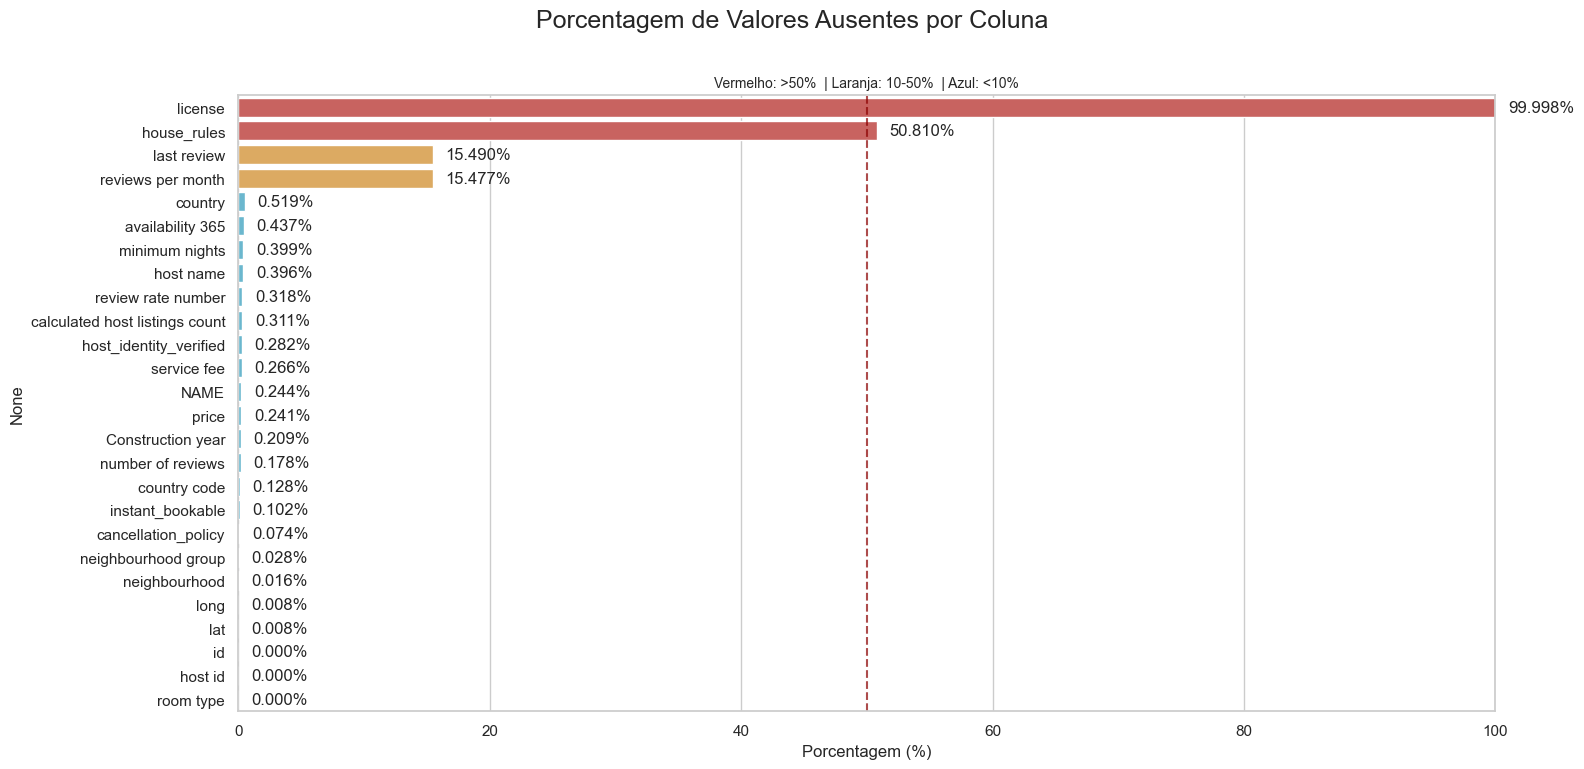

In [10]:
null_perc = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

colors = ['#d9534f' if v > 50 else '#f0ad4e' if v > 10 else '#5bc0de' for v in null_perc.values]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 8))
ax = sns.barplot(x=null_perc.values, y=null_perc.index, hue=null_perc.index, palette=colors, legend=False)

plt.suptitle("Porcentagem de Valores Ausentes por Coluna", fontsize=18, y=0.96)
ax.set_title("Vermelho: >50%  | Laranja: 10-50%  | Azul: <10%", fontsize=10)
ax.set_xlabel("Porcentagem (%)")
ax.set_xlim(0, 100)

for p in ax.patches:
    w = p.get_width()
    ax.text(w + 1, p.get_y() + p.get_height()/2, f'{w:.3f}%', va='center')

ax.axvline(50, color='darkred', linestyle='--', alpha=0.7)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Observemos algumas colunas com dados interessantes: 

- **license**: A coluna license tem apenas 2 registros que não vem com valor nulo. Todos os outros são nulos. O que torna esse campo tão importante? Por que a esmagadora maioria não precisa de uma licensa? E por que especificamente 2 anúncios tem? Existe algo que torna esses anúncios diferentes dos demais?
- **house_rules**: A coluna house_rules tem quase metade dos seus valores como nulos. Ou seja: metade dos aluguéis não vêm com regras explícitas.
- **last review**: mais de 80% dos anúncios teve pelo menos uma avaliação.
- **country** e **country code**: embora saibamos que os dados se referem sempre à cidade de Nova York, ainda assim existem registros que não indicam que o país do anúncio é os Estados Unidos.
- **id** e **name**: nenhum dos registros não tem identificador. No entanto, ainda existem registros que não tem nome (embora sejam de quantidade quase desprezível). O que levanta a pergunta: o site do airbnb permitiu anúncios sem nome? Ou houve falha no momento da extração dos dados?
- **long**, **lat**, **neighbourhood** e **neighbourhood group**: apenas 8 registros não tem latitude e longitude, mas o dobro de registros não pertence a nenhum bairro, e quase o triplo não pertence a nenhum grupo de bairro. Isso é importante porque `neighbourhood` e `neighbourhood group` são gerados a partir dos valores de latitude e longitude. Se apenas 8 registros não têm esses valores, por que 16 não tem bairro definido e 29 não tem um grupo de bairro definido?
- **price**: pouquíssimos registros não tem um preço definido. Como alguém faria um aluguel sem saber por quanto seria?

##### Distribuição de Nulos e não nulos:

<Axes: >

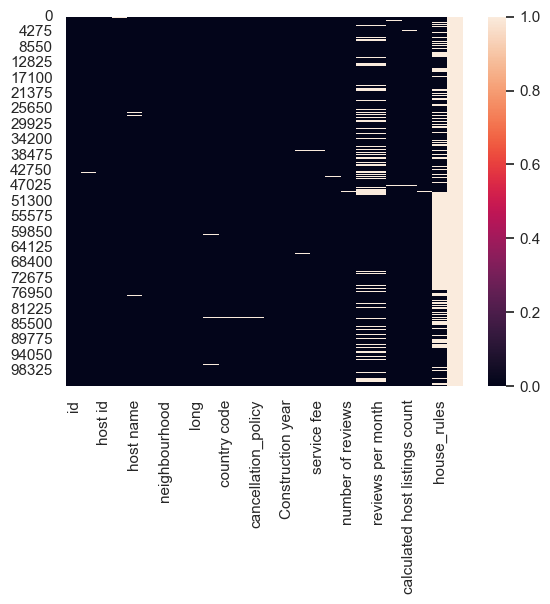

In [11]:
sns.heatmap(df.isnull())

#### 3.3.3 Duplicadas:

O objetivo é identificar anúncios idênticos no dataset. Como cada anúncio possui um identificador único (id), não deveria haver duas tuplas exatamente iguais.

In [12]:
total = len(df)
dups = df.duplicated().sum()

print(f"Total de linhas: {total}")
print(f"Total de duplicadas: {dups}")

Total de linhas: 102599
Total de duplicadas: 541


Amostra das linhas duplicadas, indicando a quantidade de ocorrências, os respectivos IDs duplicados e as posições correspondentes no dataset original:

In [13]:
resumo = (
    df.groupby([c for c in df.columns if c != "id"], dropna=False)
      .agg(ids=("id", list),
           ocorrencias=("id", "size"),
           posicoes=("id", lambda s: list(s.index)))
      .reset_index()
      .query("ocorrencias > 1")
      .sort_values("ocorrencias", ascending=False)
)

resumo = resumo[["ids","NAME","ocorrencias","posicoes"] + 
                [c for c in resumo.columns if c not in ["ids","NAME","ocorrencias","posicoes"]]]
resumo

,ids,NAME,ocorrencias,posicoes,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
101175,"[6064822, 6064822]",♡Private Rm/Women's Safe Art Home♡,2,"[9168, 102544]",27646270360,unconfirmed,Sarah,Brooklyn,Bedford-Stuyvesant,40.684110,...,$124,1.0,4.0,10/7/2015,0.08,3.0,3.0,38.0,No Smoking No Pets,NaN
109,"[20405844, 20405844]","""In the Clouds"" Brooklyn Heights Studio",2,"[35134, 102464]",7007990163,verified,Jenna,Brooklyn,Brooklyn Heights,40.695030,...,$61,8.0,1.0,9/27/2018,0.10,3.0,1.0,207.0,No Smoking and No Pets,NaN
184,"[35537207, 35537207]",# 2 One Lexury Bedroom close to JFK AIRPORT,2,"[62531, 102113]",12648350548,verified,Gelen,Queens,Springfield Gardens,40.664089,...,$189,3.0,9.0,11/10/2021,0.80,5.0,5.0,365.0,NaN,NaN
304,"[35596856, 35596856]",#510 Furnished studio in the heart of Manhattan,2,"[62639, 102221]",22417870465,verified,Best Inns USA,Manhattan,Gramercy,40.733810,...,$128,30.0,1.0,11/6/2021,0.25,5.0,20.0,124.0,NaN,NaN
558,"[35598513, 35598513]",****THE SUITE LIFE DUPLEX****,2,"[62642, 102224]",2578777349,verified,Kila,Brooklyn,Bedford-Stuyvesant,40.689760,...,$189,7.0,68.0,11/5/2021,1.01,2.0,2.0,175.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4721,"[35534998, 35534998]",2BR steps from Bell Blvd and Bayside Train Sta...,2,"[62527, 102109]",73016411582,verified,Noelle,Queens,Bayside,40.763170,...,$98,30.0,13.0,11/10/2021,0.43,2.0,4.0,349.0,NaN,NaN
4828,"[13978177, 13978177]",2bed Williamsburg Loft w Roof Access + City Views,2,"[23496, 102257]",2151054051,unconfirmed,Ashley,Brooklyn,Williamsburg,40.720590,...,$108,NaN,42.0,11/4/2018,1.71,1.0,1.0,0.0,No Smoking No Pets,NaN
5381,"[6044940, 6044940]",3BR Gramercy Apt in heart of NYC,2,"[9132, 102508]",59749079462,verified,Alissa,Manhattan,Kips Bay,40.739120,...,$85,1.0,0.0,NaN,NaN,5.0,1.0,368.0,"We only ask that you have a ton of fun, and th...",NaN
5414,"[6091333, 6091333]",3BR/1 Ba in TriBeCa w/ outdoor deck,2,"[9216, 102592]",53266862889,unconfirmed,Nick,Manhattan,Tribeca,40.718450,...,$157,1.0,0.0,NaN,NaN,2.0,1.0,177.0,Guests should treat my home as if it were thei...,NaN


##### Proporção entre duplicados e únicos:

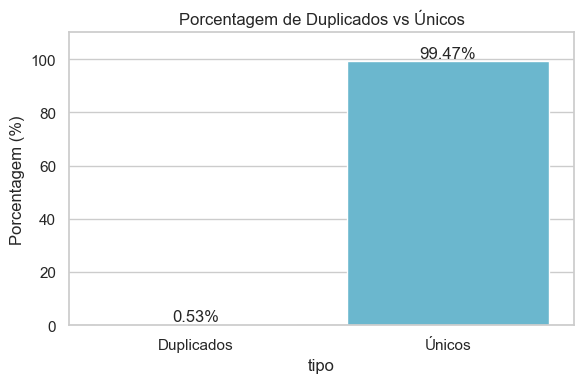

In [14]:
total = len(df)
dups = df.duplicated().sum()
stats = pd.DataFrame({
    "tipo": ["Duplicados", "Únicos"],
    "porcentagem": pd.Series([dups, total - dups]) / total * 100
})

sns.set_theme(style="whitegrid")
plt.figure(figsize=(6,4))
ax = sns.barplot(
    data=stats,
    x="tipo", y="porcentagem",
    hue="tipo", palette=["#d9534f", "#5bc0de"],
    legend=False
)

for p in ax.patches:
    h = p.get_height()
    ax.text(p.get_x()+p.get_width()/2, h+1, f"{h:.2f}%", ha="center")

ax.set_title("Porcentagem de Duplicados vs Únicos")
ax.set_ylabel("Porcentagem (%)")
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

##### Distribuição das duplicadas:

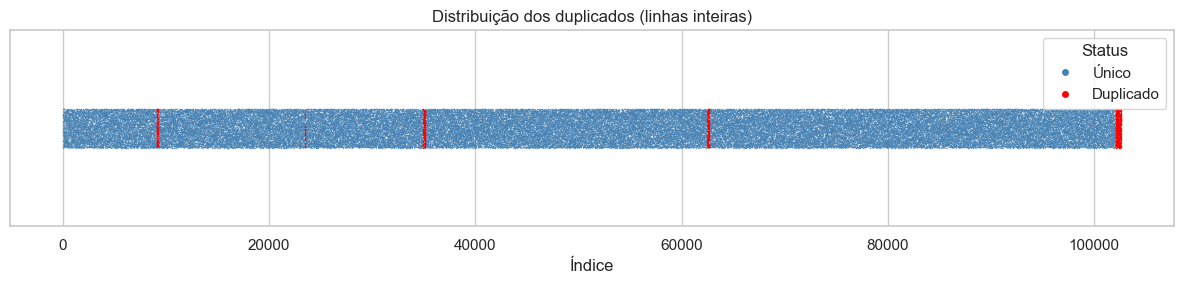

In [15]:
alpha_unico, size_unico = 0.5, 1
alpha_dup, size_dup = 1, 1

plot_df = pd.DataFrame({
    "Índice": df.index,
    "Duplicado": df.duplicated(keep=False).map({True: "Duplicado", False: "Único"})
})

fig, ax = plt.subplots(figsize=(12, 3))
sns.stripplot(data=plot_df[plot_df.Duplicado=="Único"],x="Índice",y=[""]*plot_df.Duplicado.eq("Único").sum(),
              color="steelblue",alpha=alpha_unico,size=size_unico,ax=ax)
sns.stripplot(data=plot_df[plot_df.Duplicado=="Duplicado"],x="Índice",y=[""]*plot_df.Duplicado.eq("Duplicado").sum(),
              color="red",alpha=alpha_dup,size=size_dup,ax=ax)

legend_elements=[Line2D([0],[0],marker='o',color='w',label='Único',markerfacecolor='steelblue',markersize=6),
                 Line2D([0],[0],marker='o',color='w',label='Duplicado',markerfacecolor='red',markersize=6)]
ax.legend(handles=legend_elements,title="Status",loc="upper right")

plt.title("Distribuição dos duplicados (linhas inteiras)")
plt.xlabel("Índice");plt.ylabel("")
plt.tight_layout();plt.show()

## 3.4 Breve descrição estatística:

In [16]:
df.drop(columns=["id", "host id"]).describe()

,lat,long,Construction year,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
count,102591.000000,102591.000000,102385.000000,102190.000000,102416.000000,86720.000000,102273.000000,102280.000000,102151.000000
mean,40.728094,-73.949644,2012.487464,8.135845,27.483743,1.374022,3.279106,7.936605,141.133254
std,0.055857,0.049521,5.765556,30.553781,49.508954,1.746621,1.284657,32.218780,135.435024
min,40.499790,-74.249840,2003.000000,-1223.000000,0.000000,0.010000,1.000000,1.000000,-10.000000
25%,40.688740,-73.982580,2007.000000,2.000000,1.000000,0.220000,2.000000,1.000000,3.000000
50%,40.722290,-73.954440,2012.000000,3.000000,7.000000,0.740000,3.000000,1.000000,96.000000
75%,40.762760,-73.932350,2017.000000,5.000000,30.000000,2.000000,4.000000,2.000000,269.000000
max,40.916970,-73.705220,2022.000000,5645.000000,1024.000000,90.000000,5.000000,332.000000,3677.000000


O comando **'df.describe()** é uma ferramenta de diagnóstico do pandas que gera um resumo estatístico de todas as colunas de um DataFrame, tanto as numéricas quanto as textuais. Ao aplicá-lo em nosso conjunto de dados, obtivemos um panorama da qualidade dos dados, o que nos permitiu identificar pontos candidatos para a etapa de limpeza (camada Silver).

Constatamos que colunas essenciais como **price** e **service fee** estão formatadas incorretamente como texto, e não como números. Além disso, a análise expôs erros claros, como um valor mínimo impossível de -10 para a coluna **availability_365**, e outliers em **minimum_nights**. Por fim, o resumo quantificou a alta incidência de dados ausentes em colunas como **last_review** e **house_rules**, fornecendo esses campos como indicados para a etapa de tratamento do dataset.

## 5. Limpeza de dados:

Essa etapa de limpeza dos dados abrange a remoção de valores NaN, nulos, registros duplicados e a padronização dos tipos de dados. Embora seja um processo simples, é fundamental para possibilitar análises mais detalhadas em visualizações. Sem esse tratamento, por exemplo, colunas como price, armazenadas como object, não poderiam ser interpretadas corretamente como valores numéricos.

É importante destacar que essa limpeza não deve ser confundida com o processo de ETL. Aqui, o resultado é apenas um dataframe temporário, em memória e não persistente, voltado exclusivamente para fins de visualização. Já o ETL, por sua vez, gera arquivos persistentes e atua como ponte entre as diferentes camadas do modelo Medallion.

Cria uma cópia do dataframe

In [17]:
airbnb = df.copy()

Remove colunas com mais de 50% de nulo.

In [18]:
airbnb.drop(['license', 'house_rules'], axis=1, inplace=True)

Remove registros duplicados, preservando a primeira ocorrência, e elimina aqueles que contêm valores nulos (NaN).

In [19]:
airbnb.drop_duplicates(keep="first", inplace=True)
airbnb.dropna(inplace=True)
airbnb = airbnb[airbnb != "#NAME?"].dropna()

Informações da tabela após as remoções:

In [20]:
airbnb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83390 entries, 0 to 102040
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              83390 non-null  int64  
 1   NAME                            83390 non-null  object 
 2   host id                         83390 non-null  int64  
 3   host_identity_verified          83390 non-null  object 
 4   host name                       83390 non-null  object 
 5   neighbourhood group             83390 non-null  object 
 6   neighbourhood                   83390 non-null  object 
 7   lat                             83390 non-null  float64
 8   long                            83390 non-null  float64
 9   country                         83390 non-null  object 
 10  country code                    83390 non-null  object 
 11  instant_bookable                83390 non-null  object 
 12  cancellation_policy             8339

Conversão de tipos:

In [21]:
col_types = {
    "id": "int64", "NAME": "string", "host id": "int64",
    "host_identity_verified": "string", "host name": "string",
    "neighbourhood group": "string", "neighbourhood": "string",
    "lat": "float64", "long": "float64", "country": "string",
    "country code": "string", "instant_bookable": "boolean",
    "cancellation_policy": "string", "room type": "string",
    "Construction year": "int64", "minimum nights": "int64",
    "number of reviews": "int64", "reviews per month": "float64",
    "review rate number": "int64", "calculated host listings count": "int64",
    "availability 365": "int64"
}

for col in ["price", "service fee"]:
    airbnb[col] = (
        airbnb[col]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace(" ", "", regex=False)
        .astype("int64")
    )

airbnb["last review"] = pd.to_datetime(airbnb["last review"], format="mixed", dayfirst=True, errors="coerce")

airbnb = airbnb.astype(col_types)

Tipos convertidos:

In [22]:
airbnb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83390 entries, 0 to 102040
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              83390 non-null  int64         
 1   NAME                            83390 non-null  string        
 2   host id                         83390 non-null  int64         
 3   host_identity_verified          83390 non-null  string        
 4   host name                       83390 non-null  string        
 5   neighbourhood group             83390 non-null  string        
 6   neighbourhood                   83390 non-null  string        
 7   lat                             83390 non-null  float64       
 8   long                            83390 non-null  float64       
 9   country                         83390 non-null  string        
 10  country code                    83390 non-null  string        
 11  instan

## 4. Exploração dos dados:

### Nomes dos anúncios:

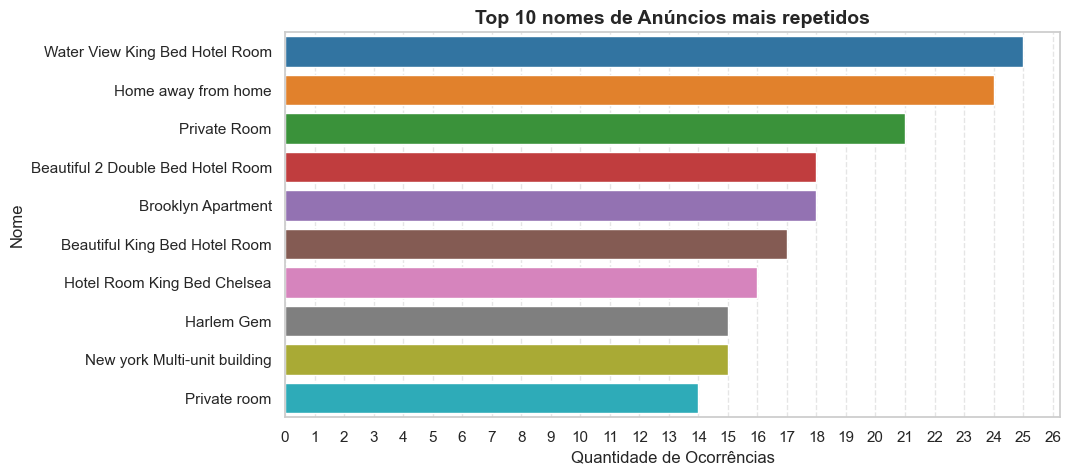

In [23]:
top_names = airbnb['NAME'].value_counts().head(10)

plt.figure(figsize=(10,5))
ax = sns.barplot(
    x=top_names.values, 
    y=top_names.index, 
    hue=top_names.index,
    dodge=False,
    legend=False,
    palette="tab10"
)

plt.title('Top 10 nomes de Anúncios mais repetidos', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de Ocorrências', fontsize=12)
plt.ylabel('Nome', fontsize=12)
ax.xaxis.set_major_locator(MaxNLocator(nbins=30))
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

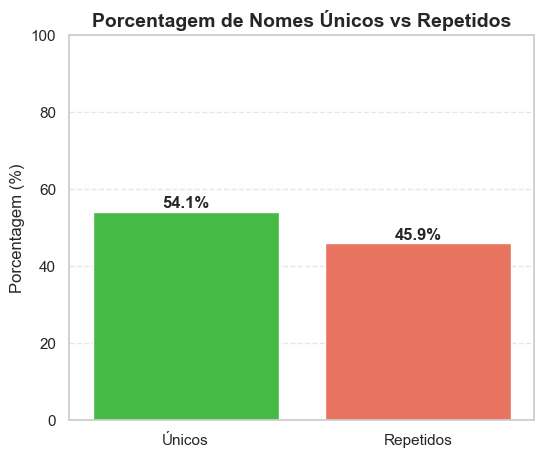

In [24]:
name_counts = airbnb['NAME'].value_counts()
unique_count = (name_counts == 1).sum()
repeated_count = (name_counts > 1).sum()

cats = ['Únicos', 'Repetidos']
vals = [unique_count / len(name_counts) * 100, repeated_count / len(name_counts) * 100]

plt.figure(figsize=(6,5))
ax = sns.barplot(x=cats, y=vals, hue=cats, dodge=False, legend=False, palette=['limegreen', 'tomato'])

plt.title('Porcentagem de Nomes Únicos vs Repetidos', fontsize=14, fontweight='bold')
plt.ylabel('Porcentagem (%)', fontsize=12)

for i, v in enumerate(vals):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')

plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


### Localização dos anúncios, tipos e relação preço-localização:

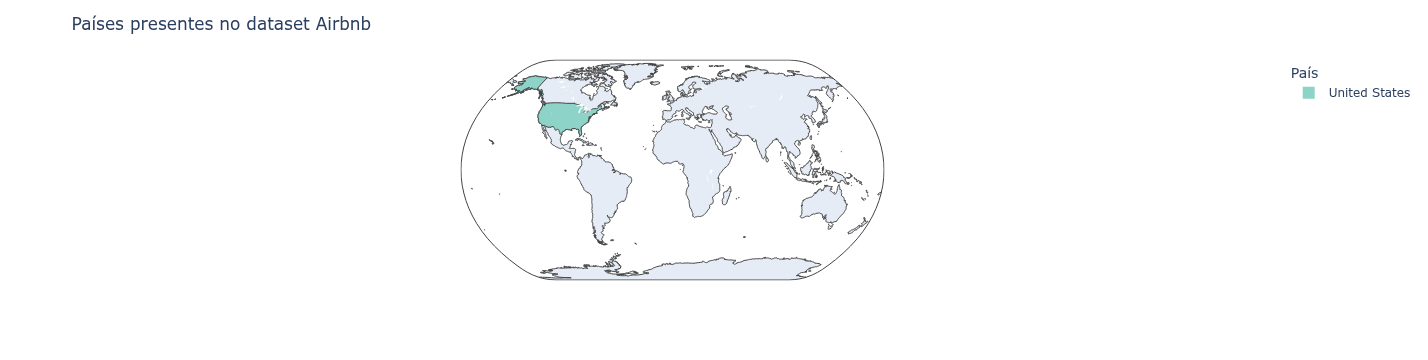

In [25]:
contagem = airbnb.groupby(['country','country code']).size().reset_index(name='Anuncios')

df_paises = pd.DataFrame({
    'Pais': contagem['country'],
    'Codigo': [
        pycountry.countries.get(alpha_2=c).alpha_3 if pycountry.countries.get(alpha_2=c) else None
        for c in contagem['country code']
    ],
    'Anuncios': contagem['Anuncios']
}).dropna()

fig = px.choropleth(
    df_paises,
    locations="Codigo",
    color="Pais",
    hover_name="Pais",
    hover_data={'Anuncios': True},
    projection="natural earth",
    locationmode="ISO-3",
    color_discrete_sequence=px.colors.qualitative.Set3
)

fig.update_layout(
    title="Países presentes no dataset Airbnb",
    legend=dict(
        title="País",
        orientation="v",
        x=1.02,
        y=1
    )
)

fig.show()

In [26]:
bairros_unicos = airbnb['neighbourhood group'].unique()
print(list(bairros_unicos))

['Brooklyn', 'Manhattan', 'brookln', 'Queens', 'Bronx', 'Staten Island']


Ao inspecionar os grupos de bairros, percebemos que existem 6 categorias únicas. No entanto, identificamos uma inconsistência clara nos dados:

- O grupo de bairro `'brookln'` deveria claramente ser `'Brooklyn'`.
- Da mesma forma, `'manhatan'` deveria ser `'Manhattan'`.

O gráfico de barras a seguir, gerado com os dados brutos, ilustra visualmente esse problema. Essa correção será aplicada em uma etapa posterior de tratamento dos dados para garantir a integridade da análise.

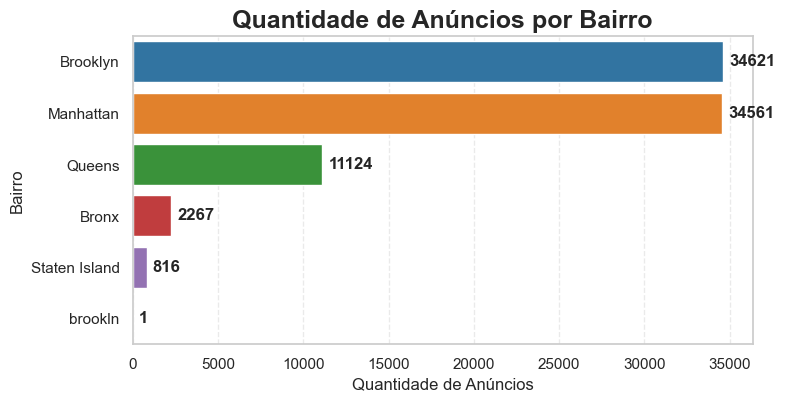

In [27]:
feq = airbnb['neighbourhood group'].value_counts()

plt.figure(figsize=(8,4))
ax = sns.barplot(
    x=feq.values, 
    y=feq.index, 
    hue=feq.index, 
    dodge=False, 
    legend=False, 
    palette="tab10"
)

plt.title("Quantidade de Anúncios por Bairro", fontsize=18, fontweight='bold')
plt.xlabel('Quantidade de Anúncios', fontsize=12)
plt.ylabel('Bairro', fontsize=12)

for i, v in enumerate(feq.values):
    ax.text(v + feq.max()*0.01, i, str(v), va='center', fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()


In [28]:
latitudes = airbnb['lat'].tolist()
longitudes = airbnb['long'].tolist()
coordenadas = list(zip(latitudes, longitudes))

mapa_nova_york = folium.Map(location=[40.7128, -74.0060], zoom_start=11.5)
FastMarkerCluster(data=coordenadas).add_to(mapa_nova_york)
mapa_nova_york

In [29]:
list(airbnb["room type"].unique())


['Private room', 'Entire home/apt', 'Shared room', 'Hotel room']

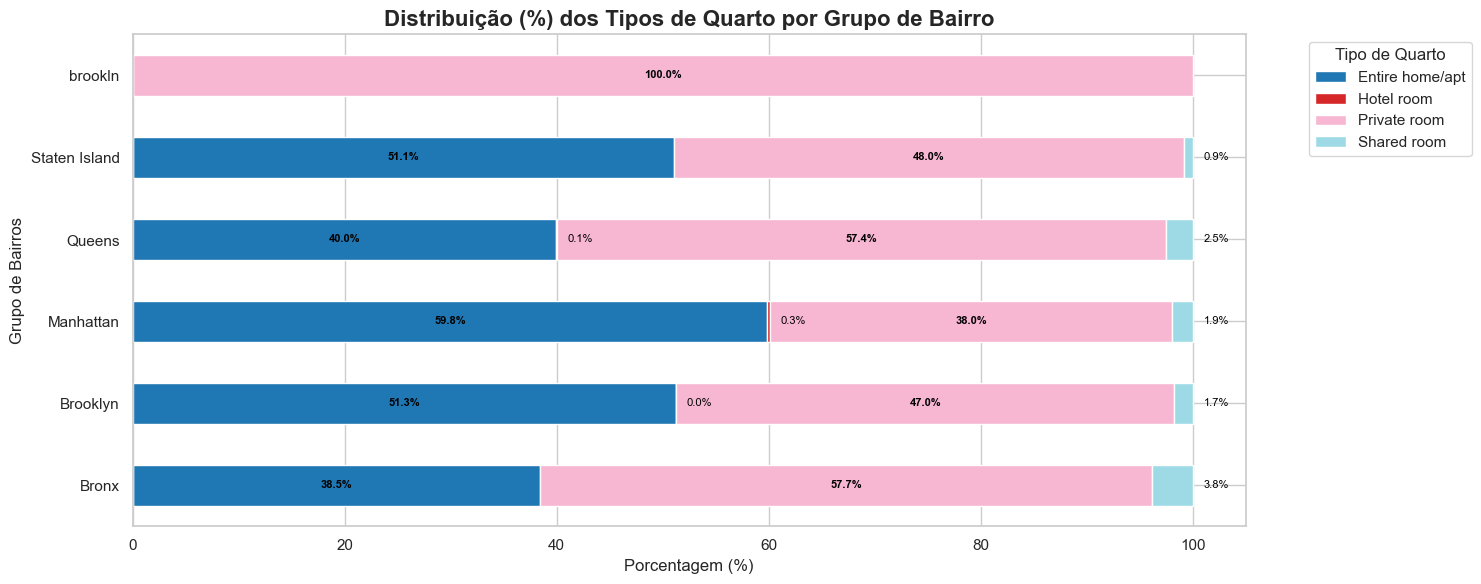

In [30]:
freq = airbnb.groupby(["neighbourhood group", "room type"]).size().reset_index(name="count")
freq["percent"] = freq.groupby("neighbourhood group")["count"].transform(lambda x: x / x.sum() * 100)

pivot = freq.pivot(index="neighbourhood group", columns="room type", values="percent").fillna(0)

ax = pivot.plot(
    kind="barh",
    stacked=True,
    figsize=(15, 6),
    colormap="tab20"
)

plt.title("Distribuição (%) dos Tipos de Quarto por Grupo de Bairro", fontsize=16, fontweight="bold")
plt.xlabel("Porcentagem (%)", fontsize=12)
plt.ylabel("Grupo de Bairros", fontsize=12)
plt.legend(title="Tipo de Quarto", bbox_to_anchor=(1.05, 1), loc="upper left")

for bar in ax.patches:
    width = bar.get_width()
    if width > 0:
        x = bar.get_x() + width / 2
        y = bar.get_y() + bar.get_height() / 2
        label = f"{width:.1f}%"
        if width > 8:
            ax.text(x, y, label, ha="center", va="center", fontsize=8, color="black", fontweight="bold")
        else:
            ax.text(bar.get_x() + width + 1, y, label, ha="left", va="center", fontsize=8, color="black")

plt.tight_layout()
plt.show()


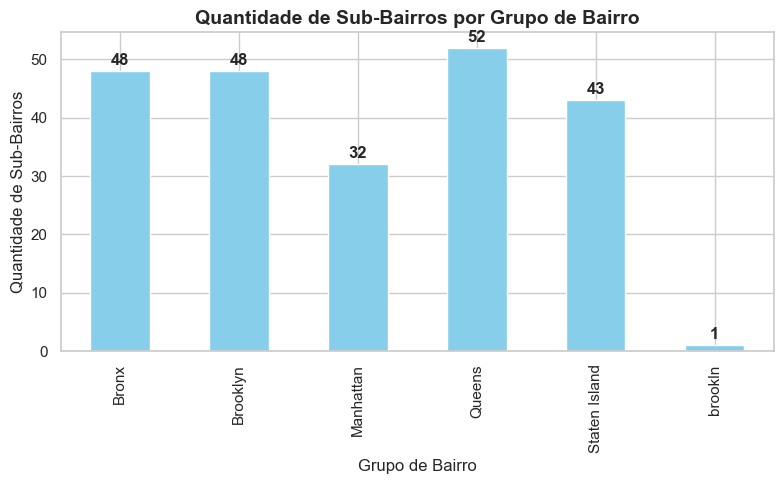

In [31]:
contagem = airbnb.groupby("neighbourhood group")["neighbourhood"].nunique().reset_index()
contagem.columns = ["Grupo de Bairro", "Qtd. de Sub-Bairros"]

ax = contagem.plot(
    x="Grupo de Bairro",
    y="Qtd. de Sub-Bairros",
    kind="bar",
    figsize=(8,5),
    legend=False,
    color="skyblue"
)

plt.title("Quantidade de Sub-Bairros por Grupo de Bairro", fontsize=14, fontweight="bold")
plt.xlabel("Grupo de Bairro", fontsize=12)
plt.ylabel("Quantidade de Sub-Bairros", fontsize=12)

for i, v in enumerate(contagem["Qtd. de Sub-Bairros"]):
    ax.text(i, v + 0.5, str(v), ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()


In [37]:
geojson_path = "nyc.geojson"
regioes = gpd.read_file(geojson_path).to_crs("EPSG:4326").reset_index().rename(columns={"index":"id_poligono"})

pontos = airbnb.dropna(subset=["lat","long"])[["lat","long"]]
pontos = gpd.GeoDataFrame(pontos, geometry=gpd.points_from_xy(pontos["long"], pontos["lat"]), crs="EPSG:4326")

juncao = gpd.sjoin(pontos, regioes, how="inner", predicate="within")
contagem = juncao.groupby("id_poligono").size().reset_index(name="anuncios")

regioes = regioes.merge(contagem, on="id_poligono", how="left")
regioes["anuncios"] = regioes["anuncios"].fillna(0).astype(int)

boroughs_validos = sorted(regioes.loc[regioes["anuncios"]>0, "BoroName"].dropna().unique())
cmap = plt.colormaps.get_cmap("tab10")
cores_borough = {b: mcolors.rgb2hex(cmap(i/len(boroughs_validos))) for i, b in enumerate(boroughs_validos)}

def estilo(f):
    a = f["properties"].get("anuncios", 0)
    b = f["properties"].get("BoroName")
    if a>0 and b in cores_borough:
        return {"fillColor": cores_borough[b], "color": "black", "weight": 1, "fillOpacity": 0.7, "opacity": 1}
    return {"fillColor": "transparent", "color": "transparent", "weight": 0, "fillOpacity": 0, "opacity": 0}

def destaque(f):
    a = f["properties"].get("anuncios", 0)
    b = f["properties"].get("BoroName")
    cor = cores_borough.get(b, "#cccccc")
    return {"weight": 3, "fillColor": cor, "fillOpacity": 0.9 if a>0 else 0}

mapa = folium.Map(location=[40.7128, -74.0060], zoom_start=11)
folium.GeoJson(
    regioes,
    tooltip=folium.GeoJsonTooltip(
        fields=[c for c in ["BoroName","NTAName","anuncios"] if c in regioes.columns],
        aliases=["Bairro","Sub-região","Anúncios"]
    ),
    style_function=estilo,
    highlight_function=destaque
).add_to(mapa)
mapa


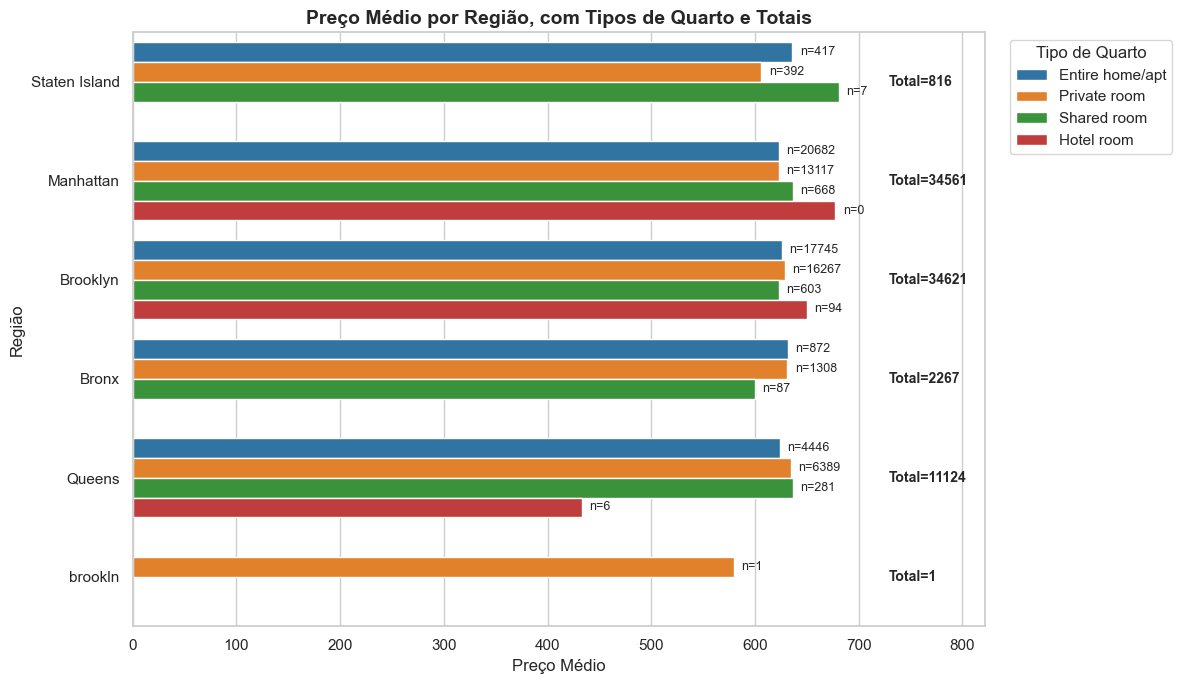

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ---- agregações ----
media_rt = (
    airbnb.groupby(["neighbourhood group","room type"])["price"]
    .mean()
    .reset_index(name="PrecoMedio")
)

contagem_rt = (
    airbnb.groupby(["neighbourhood group","room type"])
    .size()
    .reset_index(name="n")
)

totais_regiao = (
    airbnb.groupby("neighbourhood group")
    .size()
    .rename("Total")
    .reset_index()
)

# base para plot (média + n por combinação)
base = media_rt.merge(contagem_rt, on=["neighbourhood group","room type"], how="left")

# ordem das regiões por preço médio (média das médias por região)
ordem_regioes = (
    base.groupby("neighbourhood group")["PrecoMedio"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)
ordem_tipos = base["room type"].unique().tolist()

# ---- plot ----
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=base,
    x="PrecoMedio", y="neighbourhood group",
    hue="room type", hue_order=ordem_tipos,
    order=ordem_regioes, dodge=True, palette="tab10"
)

# anotar "n" (quantidade) em cada barra
# mapeia (regiao, tipo) -> n
map_n = {(r,t): n for r,t,n in contagem_rt[["neighbourhood group","room type","n"]].itertuples(index=False)}
for p in ax.patches:
    # cada patch é uma barra de um tipo em uma região
    width = p.get_width()
    if width <= 0: 
        continue
    y = p.get_y() + p.get_height()/2
    # descobrir rótulos da barra (região e tipo) pelo tick e posição
    # truque: usar dados do artista ancorados no seaborn (ordem e hue)
    # aproximação: pegar o índice de região pela coordenada y do patch
    # e o tipo pelo ciclo dos patches dentro de cada linha
    # mais robusto: usar o dataset base ordenado e iterar junto
    ax.text(width + 0.02*ax.get_xlim()[1], y, f"n={map_n.get( (ordem_regioes[int(round(y/ (p.get_height())))] if False else None), None)}",
            va="center")  # placeholder

# --------
# A forma acima é complicada para casar patch->(região,tipo). Faremos de modo robusto:
ax.clear()
sns.barplot(
    data=base.assign(_ord=base["neighbourhood group"].map({r:i for i,r in enumerate(ordem_regioes)})),
    x="PrecoMedio", y="neighbourhood group",
    hue="room type", hue_order=ordem_tipos,
    order=ordem_regioes, dodge=True, palette="tab10", ax=ax
)

# agora anotamos percorrendo novamente pelo dataframe ordenado por região e tipo,
# usando os "containers" que o seaborn/mpl cria por hue.
containers = ax.containers  # um container por nível de hue
# criar um mapeamento (regiao, tipo) -> n
map_n = {(r,t): n for r,t,n in contagem_rt.itertuples(index=False)}
for container, tipo in zip(containers, ordem_tipos):
    for bar, regiao in zip(container, ordem_regioes):
        w = bar.get_width()
        if w <= 0: 
            continue
        y = bar.get_y() + bar.get_height()/2
        n_val = map_n.get((regiao, tipo), 0)
        ax.text(w + 0.01*ax.get_xlim()[1], y, f"n={n_val}", va="center", fontsize=9)

# adicionar "Total" por região à direita
limite = ax.get_xlim()[1]
tot_map = dict(zip(totais_regiao["neighbourhood group"], totais_regiao["Total"]))
for tick, regiao in zip(ax.get_yticklabels(), ordem_regioes):
    y = tick.get_position()[1]
    ax.text(limite*1.02, y, f"Total={tot_map.get(regiao,0)}", va="center", fontsize=10, fontweight="bold")

ax.set_title("Preço Médio por Região, com Tipos de Quarto e Totais", fontsize=14, fontweight="bold")
ax.set_xlabel("Preço Médio")
ax.set_ylabel("Região")
ax.legend(title="Tipo de Quarto", bbox_to_anchor=(1.02, 1), loc="upper left")
# ampliar limite X para caber textos
ax.set_xlim(0, limite*1.15)
plt.tight_layout()
plt.show()


Para cancelar uma reserva, sabemos que as regras para fazê-lo podem ser "estritas", "moderadas" ou "flexíveis". No entanto, não sabemos o que isso significa. O que quer dizer que as regras para cancelar um quarto são flexíveis? Qual a diferença de flexível para moderada?

O Gráfico abaixo visa demonstrar a distribuição das políticas de cancelamento entre os anúncios.

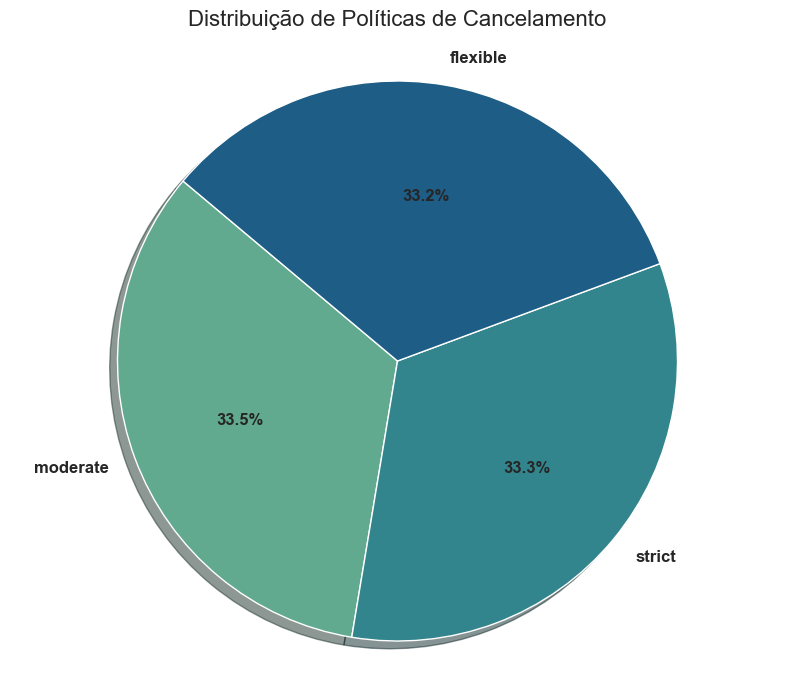

In [33]:
cancellation_counts = df['cancellation_policy'].dropna().value_counts()

sns.set_style("whitegrid")
plt.figure(figsize=(10, 8))

colors = sns.color_palette('crest', len(cancellation_counts))

plt.pie(
    cancellation_counts,
    labels=cancellation_counts.index,
    autopct='%1.1f%%',  
    startangle=140,      
    colors=colors,
    shadow=True,         
    textprops={'fontsize': 12, 'weight': 'bold'} 
)

plt.title('Distribuição de Políticas de Cancelamento', fontsize=16, pad=20)
plt.ylabel('') 
plt.axis('equal')  

plt.show()


Observamos que as três principais políticas de cancelamento – flexible, moderate e strict – estão distribuídas de maneira equilibrada, cada uma correspondendo a aproximadamente um terço do total de anúncios.

- Strict (Rígida): 33.3%
- Moderate (Moderada): 33.5%
- Flexible (Flexível): 33.2%

## Tipos de quartos

In [34]:
room_types = df['room type'].unique()

room_types

array(['Private room', 'Entire home/apt', 'Shared room', 'Hotel room'],
      dtype=object)

Existem, interessantemente, apenas quatro tipos de acomodações disponíveis para reserva: **Quarto Privado**, **Casa/Apto Inteiro**, **Quarto Compartilhado** e **Quarto de Hotel**. 

O gráfico a seguir demonstra a distribuição percentual entre esses tipos.


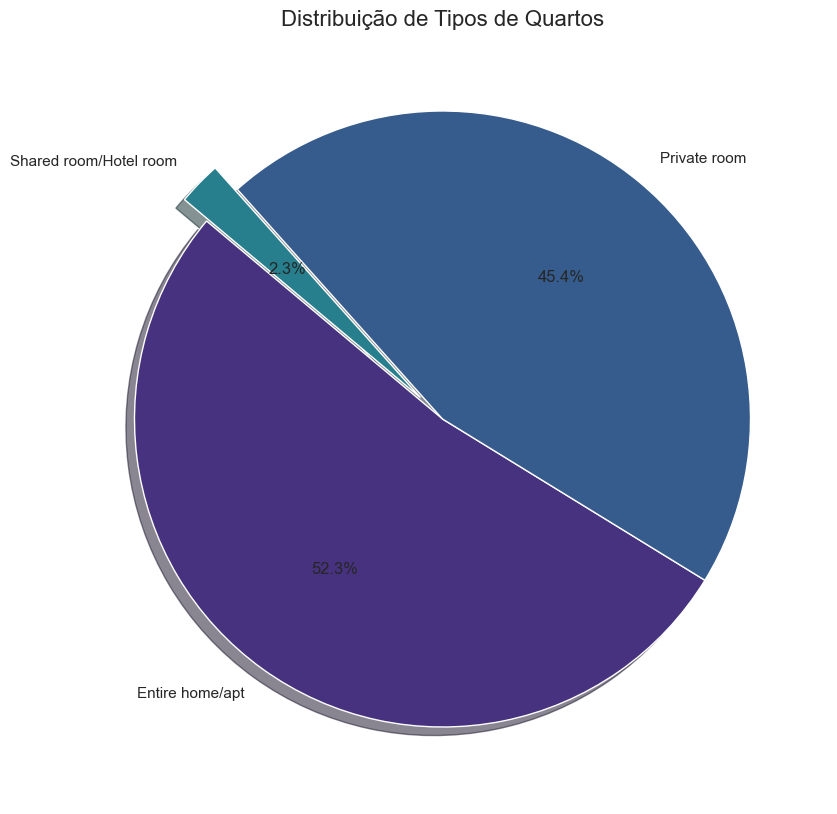

In [35]:
df_copy = df.copy()
df_copy['room_type_grouped'] = df_copy['room type'].replace({
    'Shared room': 'Shared room/Hotel room',
    'Hotel room': 'Shared room/Hotel room'
})

room_type_counts = df_copy['room_type_grouped'].value_counts()

sns.set_style("whitegrid")
sns.set_palette("viridis")

labels = room_type_counts.index
explode_values = [0.1 if label == 'Shared room/Hotel room' else 0 for label in labels]

plt.figure(figsize=(10, 10))

wedges, texts, autotexts = plt.pie(
    room_type_counts,
    autopct='%1.1f%%',
    startangle=140,
    explode=explode_values,
    shadow=True,
    labels=labels
)

plt.title('Distribuição de Tipos de Quartos', fontsize=16)
plt.ylabel('')

plt.show()

## Regras da casa Vs Avaliações

Para entender se a clareza nas regras influencia a satisfação do hóspede, investigamos se existe uma correlação entre a presença de regras da casa **(`house_rules`)** e as notas de avaliação. 
Dividimos os anúncios em dois grupos, com e sem regras definidas e comparamos a nota média de avaliação de cada um. 
O gráfico a seguir ilustra essa comparação, buscando identificar se anfitriões que definem regras tendem a receber notas mais altas.



## Regras da Casa

Para entender a frequência com que os anfitriões definem essas diretrizes, analisamos a coluna house_rules, verificando a proporção de anúncios que possuem este campo preenchido (não nulo) em comparação com os que não possuem (nulo).

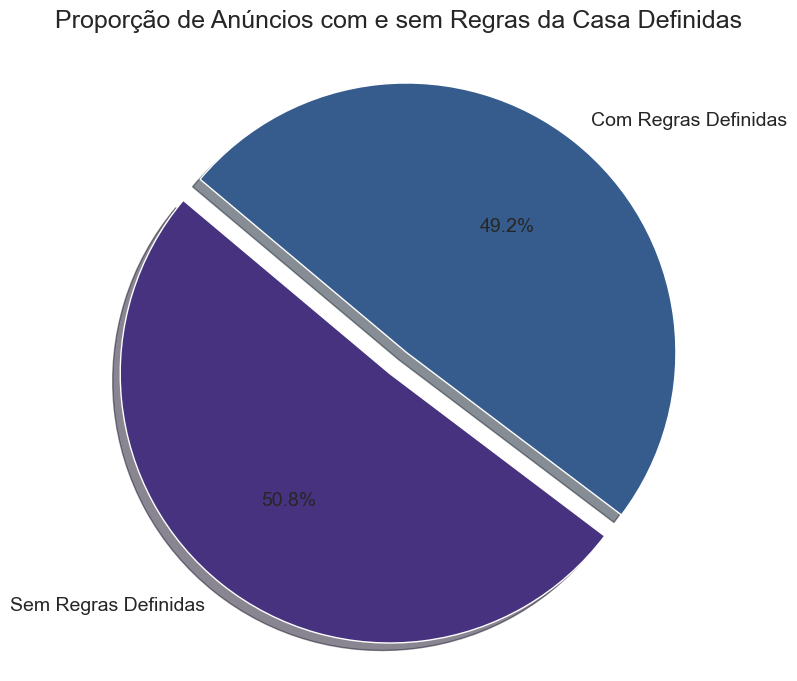

In [36]:
df_temp = df.copy()

df_temp['has_house_rules'] = df_temp['house_rules'].notna().map({True: 'Com Regras Definidas', False: 'Sem Regras Definidas'})

counts = df_temp['has_house_rules'].value_counts()

sns.set_theme(style="whitegrid", palette="viridis")


plt.figure(figsize=(10, 8))


labels = counts.index
sizes = counts.values
explode = (0.1, 0)


plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    explode=explode,
    shadow=True,
    textprops={'fontsize': 14}
)


plt.title('Proporção de Anúncios com e sem Regras da Casa Definidas', fontsize=18, pad=20)
plt.axis('equal')


plt.show()